# 04 — Simulation-based power

This notebook demonstrates **simulation-based power analysis** in `causalx`.

Why simulation-based power?
- Closed-form formulas work well for standard settings (e.g., two-sample means/proportions).
- But for **nonstandard estimators**, **heavy-tailed outcomes**, **covariate adjustment**, **clustered designs**, or **complex pipelines**, analytic approximations can be misleading.
- Simulation-based power lets you **mirror your planned analysis** by simulating data and re-running the same test/estimator repeatedly.

We'll show:
1. A minimal example (two-sample difference in means).
2. Power as a function of **effect size**.
3. Power as a function of **sample size**.
4. Using `simulated_power_grid` for a small effect grid.


In [3]:
# %pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 16.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 27.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causalx.sampling.simulated_power import simulated_power, simulated_power_grid

Matplotlib is building the font cache; this may take a moment.


## 1) Define a data generating process (DGP)

Simulation-based power has two moving pieces:

- `simulate_data(n, effect, rng)`  
  Generates one synthetic dataset under a given "effect specification".
- `test_statistic(data)` **or** `p_value(data)`  
  Computes the test statistic (or p-value) using the same analysis logic you plan to use in real life.

In this example:
- Two-arm experiment (control vs treatment)
- Continuous outcome with Normal noise
- Effect is the difference in means: `mu_t - mu_c`


In [5]:
def simulate_normal_means(n: int, effect: dict, rng: np.random.Generator):
    """
    Two-arm continuous outcome:
      Control:    y ~ Normal(mu_c, sigma)
      Treatment:  y ~ Normal(mu_t, sigma)
    """
    sigma = effect["sigma"]
    mu_c = effect.get("mu_c", 0.0)
    mu_t = effect.get("mu_t", mu_c)

    n_t = n // 2
    n_c = n - n_t

    y_c = rng.normal(loc=mu_c, scale=sigma, size=n_c)
    y_t = rng.normal(loc=mu_t, scale=sigma, size=n_t)
    return {"y_c": y_c, "y_t": y_t}


def z_like_stat_diff_in_means(data) -> float:
    """
    A simple standardized difference in means:
      stat = (mean_t - mean_c) / SE
    Under typical assumptions this is approximately Normal under H0.
    We use it purely as a test statistic to compare against an empirical null.
    """
    y_c = data["y_c"]
    y_t = data["y_t"]
    diff = float(np.mean(y_t) - np.mean(y_c))
    se = float(np.sqrt(np.var(y_t, ddof=1) / len(y_t) + np.var(y_c, ddof=1) / len(y_c)))
    return diff / se

In [6]:
## Sanity check for the data-generating process

rng = np.random.default_rng(0)
demo = simulate_normal_means(10, {"mu_c": 0.0, "mu_t": 0.5, "sigma": 1.0}, rng)
np.mean(demo["y_t"]) - np.mean(demo["y_c"])

np.float64(0.5880481208157035)

## 2) Single power estimate

We simulate:
- a **null distribution** of the test statistic (H0: no effect)
- many **alternative datasets** (H1: effect present)
and reject if the empirical p-value is ≤ `alpha`.

Key parameters:
- `ndistr`: number of null simulations (more → more stable p-values)
- `npower`: number of alternative simulations (more → lower Monte Carlo error in the power estimate)

For a quick demo, we use moderate values that run fast in a notebook.


In [8]:
null = {"mu_c": 0.0, "mu_t": 0.0, "sigma": 1.0}
alt = {"mu_c": 0.0, "mu_t": 0.3, "sigma": 1.0}

res = simulated_power(
    n=200,
    simulate_data=simulate_normal_means,
    null_effect=null,
    alt_effect=alt,
    alpha=0.05,
    npower=800,
    ndistr=1200,
    direction="two-sided",
    seed=123,
    test_statistic=z_like_stat_diff_in_means,
)

res

SimulatedPowerResult(n=200, alpha=0.05, npower=800, ndistr=1200, direction='two-sided', power=0.5925, mc_se=0.01737252680239694, n_reject=474, null_stat_summary={'mean': -0.0006410402671795334, 'std': 0.9957737198932601, 'q01': -2.3054941399508047, 'q05': -1.5858097205787187, 'q50': 0.010356344746603307, 'q95': 1.6542308403611934, 'q99': 2.239676102762241}, meta={'mode': 'empirical_null'})

### Interpreting the result

- `power`: estimated probability of rejecting H0 when the alternative is true
- `mc_se`: Monte Carlo standard error of the power estimate (simulation uncertainty)
- `null_stat_summary`: summary of the empirical null distribution of the test statistic


## 3) Power vs effect size

A common workflow is to plot power as you vary the assumed treatment effect.


In [9]:
effects = np.linspace(0.0, 0.6, 7)  # mu_t - mu_c
rows = []

for eff in effects:
    alt_eff = {"mu_c": 0.0, "mu_t": float(eff), "sigma": 1.0}
    r = simulated_power(
        n=200,
        simulate_data=simulate_normal_means,
        null_effect=null,
        alt_effect=alt_eff,
        alpha=0.05,
        npower=600,
        ndistr=900,
        direction="two-sided",
        seed=100 + int(eff * 1000),
        test_statistic=z_like_stat_diff_in_means,
    )
    rows.append({"effect": eff, "power": r.power, "mc_se": r.mc_se})

df_eff = pd.DataFrame(rows)
df_eff

,effect,power,mc_se
0,0.0,0.050000,0.008898
1,0.1,0.103333,0.012427
2,0.2,0.316667,0.018991
3,0.3,0.643333,0.019556
4,0.4,0.798333,0.016381
5,0.5,0.941667,0.009568
6,0.6,0.995000,0.002880


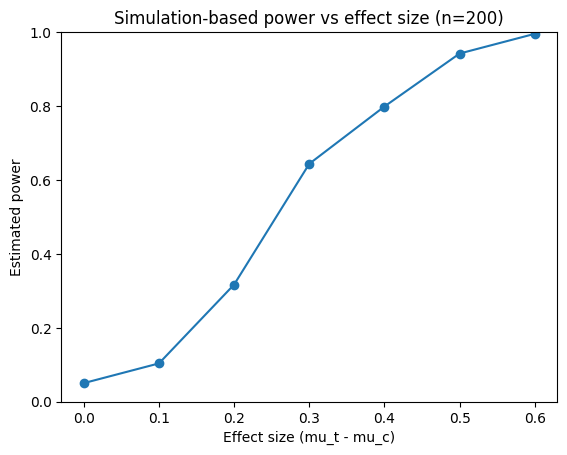

In [10]:
plt.figure()
plt.plot(df_eff["effect"], df_eff["power"], marker="o")
plt.xlabel("Effect size (mu_t - mu_c)")
plt.ylabel("Estimated power")
plt.ylim(0, 1)
plt.title("Simulation-based power vs effect size (n=200)")
plt.show()

## 4) Power vs sample size

Another common workflow is to find the smallest N that achieves a desired power.


In [11]:
ns = [50, 100, 150, 200, 300, 400]
alt_fixed = {"mu_c": 0.0, "mu_t": 0.3, "sigma": 1.0}

rows = []
for n in ns:
    r = simulated_power(
        n=n,
        simulate_data=simulate_normal_means,
        null_effect=null,
        alt_effect=alt_fixed,
        alpha=0.05,
        npower=600,
        ndistr=900,
        direction="two-sided",
        seed=2000 + n,
        test_statistic=z_like_stat_diff_in_means,
    )
    rows.append({"n": n, "power": r.power, "mc_se": r.mc_se})

df_n = pd.DataFrame(rows)
df_n

,n,power,mc_se
0,50,0.171667,0.015395
1,100,0.315000,0.018964
2,150,0.410000,0.020079
3,200,0.591667,0.020066
4,300,0.741667,0.017870
5,400,0.860000,0.014166


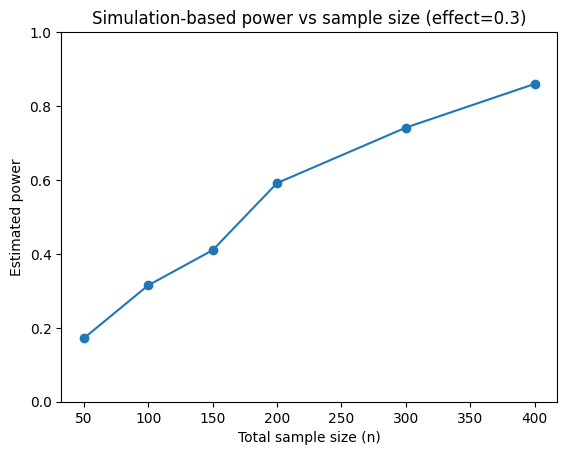

In [12]:
plt.figure()
plt.plot(df_n["n"], df_n["power"], marker="o")
plt.xlabel("Total sample size (n)")
plt.ylabel("Estimated power")
plt.ylim(0, 1)
plt.title("Simulation-based power vs sample size (effect=0.3)")
plt.show()

## 5) `simulated_power_grid`

`simulated_power_grid` is a convenience wrapper to run a list of alternative effects.
It's useful when you want to scan a small grid of scenarios.


In [13]:
grid_effects = [
    {"mu_c": 0.0, "mu_t": 0.1, "sigma": 1.0},
    {"mu_c": 0.0, "mu_t": 0.2, "sigma": 1.0},
    {"mu_c": 0.0, "mu_t": 0.3, "sigma": 1.0},
]

grid = simulated_power_grid(
    n=200,
    effects=grid_effects,
    simulate_data=simulate_normal_means,
    null_effect=null,
    alpha=0.05,
    npower=500,
    ndistr=800,
    direction="two-sided",
    seed=7,
    test_statistic=z_like_stat_diff_in_means,
)

pd.DataFrame(
    {
        "mu_t": [e["mu_t"] for e in grid.effects],
        "power": [r.power for r in grid.results],
        "mc_se": [r.mc_se for r in grid.results],
        "n": [r.n for r in grid.results],
    }
)

,mu_t,power,mc_se,n
0,0.1,0.098,0.013296,200
1,0.2,0.264,0.019713,200
2,0.3,0.578,0.022087,200


## Notes and extensions

This example used a simple difference-in-means test statistic.

The main value of simulation-based power is that you can plug in:
- covariate adjustment (e.g., regression / CUPED)
- robust or clustered standard errors
- trimming / overlap checks
- non-normal outcomes (e.g., log-normal, t-distribution)
- marketplace or network interference simulators

As long as you can simulate data and compute a statistic (or p-value), you can estimate power.
